In [1]:
# =================== IMPORTS ===================
import os
import numpy as np
import random
import tensorflow as tf
import time
from tensorflow.keras import layers, models, callbacks, backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from keras.optimizers import AdamW
from tensorflow.keras.losses import CategoricalCrossentropy
from shutil import rmtree, copyfile
from tqdm import tqdm
from tensorflow.keras import mixed_precision


# =================== REPRODUCIBILITY (ADDED) ===================
SEED = 40
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# =================== CUSTOM LAYERS ===================
@tf.keras.utils.register_keras_serializable()
class MeanChannel(layers.Layer):
    def call(self, inputs):
        return tf.reduce_mean(inputs, axis=-1, keepdims=True)


@tf.keras.utils.register_keras_serializable()
class MaxChannel(layers.Layer):
    def call(self, inputs):
        return tf.reduce_max(inputs, axis=-1, keepdims=True)


# =================== ENABLE MIXED PRECISION ===================
mixed_precision.set_global_policy('mixed_float16')


# =================== CONSTANTS ===================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 4
EPOCHS = 60
train_ratio, val_ratio = 0.7, 0.15


# =================== DIRECTORIES ===================
dataset_dir = '/kaggle/input/datasets/mariyahossan/colon-augmented-custom/colon_augmented_png_v9'
base_dir = '/kaggle/working/colon_split'


# =================== CLEAN EXISTING SPLITS ===================
if os.path.exists(base_dir):
    for folder in os.listdir(base_dir):
        rmtree(os.path.join(base_dir, folder))


# =================== DATA SPLIT ===================
splits = ['train', 'val', 'test']
class_names = os.listdir(dataset_dir)

for split in splits:
    for class_name in class_names:
        os.makedirs(os.path.join(base_dir, split, class_name), exist_ok=True)

for class_name in class_names:
    image_list = os.listdir(os.path.join(dataset_dir, class_name))
    random.shuffle(image_list)

    n_total = len(image_list)
    n_train = int(train_ratio * n_total)
    n_val = int(val_ratio * n_total)

    train_files = image_list[:n_train]
    val_files = image_list[n_train:n_train + n_val]
    test_files = image_list[n_train + n_val:]

    for split, split_files in zip(['train', 'val', 'test'], [train_files, val_files, test_files]):
        for img in tqdm(split_files, desc=f'{class_name} - {split}'):
            src = os.path.join(dataset_dir, class_name, img)
            dst = os.path.join(base_dir, split, class_name, img)
            copyfile(src, dst)


# =================== DATA GENERATORS ===================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

val_test_datagen = ImageDataGenerator(rescale=1./255)


train_generator = train_datagen.flow_from_directory(
    os.path.join(base_dir, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


# =================== MODEL BUILDING ===================
def cbam_block(input_feature, ratio=8):
    channel = input_feature.shape[-1]

    avg_pool = layers.GlobalAveragePooling2D()(input_feature)
    max_pool = layers.GlobalMaxPooling2D()(input_feature)

    shared_dense_one = layers.Dense(channel // ratio, activation='relu')
    shared_dense_two = layers.Dense(channel)

    mlp_avg = shared_dense_two(shared_dense_one(avg_pool))
    mlp_max = shared_dense_two(shared_dense_one(max_pool))

    channel_attention = layers.Add()([mlp_avg, mlp_max])
    channel_attention = layers.Activation('sigmoid')(channel_attention)
    channel_attention = layers.Reshape((1, 1, channel))(channel_attention)

    x = layers.Multiply()([input_feature, channel_attention])

    avg_pool_spatial = MeanChannel()(x)
    max_pool_spatial = MaxChannel()(x)
    concat = layers.Concatenate(axis=-1)([avg_pool_spatial, max_pool_spatial])
    spatial_attention = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)

    refined_feature = layers.Multiply()([x, spatial_attention])
    return refined_feature


def build_model():
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False, input_shape=(224, 224, 3), weights='imagenet'
    )
    base_model.trainable = True

    inputs = layers.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=True)
    x = cbam_block(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)

    model = tf.keras.Model(inputs, outputs)
    return model


model = build_model()


# =================== OPTIMIZER & LOSS ===================
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1.5e-4,
    decay_steps=1000,
    alpha=1e-6
)

optimizer = AdamW(learning_rate=lr_schedule, weight_decay=1e-5)
loss_fn = CategoricalCrossentropy(label_smoothing=0.1)

model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])


# =================== PARAMETER COUNT ===================
trainable_params = np.sum([K.count_params(w) for w in model.trainable_weights])
non_trainable_params = np.sum([K.count_params(w) for w in model.non_trainable_weights])
total_params = trainable_params + non_trainable_params

print(f"\n📊 Model Parameter Counts:")
print(f"  Total: {total_params:,}")
print(f"  Trainable: {trainable_params:,}")
print(f"  Non-trainable: {non_trainable_params:,}\n")


# =================== CALLBACKS ===================
checkpoint_cb = callbacks.ModelCheckpoint(
    'carenet.keras', monitor='val_accuracy', save_best_only=True, verbose=1
)

earlystop_cb = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=7, restore_best_weights=True
)


# =================== TRAINING WITH TIMING ===================
start_time = time.time()

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[checkpoint_cb, earlystop_cb],
    verbose=1
)

end_time = time.time()
total_training_time = end_time - start_time
avg_epoch_time = total_training_time / len(history.epoch)

print(f"\n⏱️ Total Training Time: {total_training_time:.2f} seconds")
print(f"⏱️ Average Time per Epoch: {avg_epoch_time:.2f} seconds")


# =================== EVALUATION ===================
model.load_weights("carenet.keras")
test_loss, test_acc = model.evaluate(test_generator)

print(f"\n✅ Test Accuracy: {test_acc:.4f}")

2026-03-08 09:18:08.372985: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772961488.596984      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772961488.657651      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772961489.148808      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772961489.148848      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772961489.148852      55 computation_placer.cc:177] computation placer alr

Found 4200 images belonging to 4 classes.
Found 900 images belonging to 4 classes.


Found 900 images belonging to 4 classes.


I0000 00:00:1772961591.320828      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772961591.326812      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

📊 Model Parameter Counts:
  Total: 5,118,634.0
  Trainable: 5,076,611
  Non-trainable: 42,023.0



...

Epoch 1/60


I0000 00:00:1772961635.529517     145 service.cc:152] XLA service 0x7d6f24003770 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772961635.529554     145 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772961635.529558     145 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772961644.775816     145 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-08 09:21:46.134880: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-08 09:21:46.275619: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-08 09:21:53.211767: E external/local_xl

  8/132 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - accuracy: 0.2659 - loss: 1.3983

2026-03-08 09:24:08.800344: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-08 09:24:08.946307: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-08 09:24:16.232507: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-08 09:24:16.384644: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-08 09:24:16.556089: E external/local_xla/xla/stream_

132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6134 - loss: 1.0145
Epoch 1: val_accuracy improved from -inf to 0.24778, saving model to carenet.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 381s 1s/step - accuracy: 0.6148 - loss: 1.0125 - val_accuracy: 0.2478 - val_loss: 1.3872
Epoch 2/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9490 - loss: 0.4766
Epoch 2: val_accuracy improved from 0.24778 to 0.39333, saving model to carenet.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 14s 104ms/step - accuracy: 0.9491 - loss: 0.4765 - val_accuracy: 0.3933 - val_loss: 1.2867
Epoch 3/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9741 - loss: 0.4192
Epoch 3: val_accuracy improved from 0.39333 to 0.63222, saving model to carenet.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 14s 104ms/step - accuracy: 0.9741 - loss: 0.4191 - val_accuracy: 0.6322 - val_loss: 1.0766
Epoch 4/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9869 - loss: 0.3998
Epoch 4: val_accuracy improved from 0.63222 to 0.718

In [9]:
pip install graphviz pydot matplotlib opencv-python

Note: you may need to restart the kernel to use updated packages.


/tmp/ipykernel_55/787829422.py:167: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Serif.
  plt.tight_layout(rect=[0,0,1,0.95])
/tmp/ipykernel_55/787829422.py:168: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Serif.
  plt.savefig("carenet_ablation_annotated.png", dpi=1200)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)


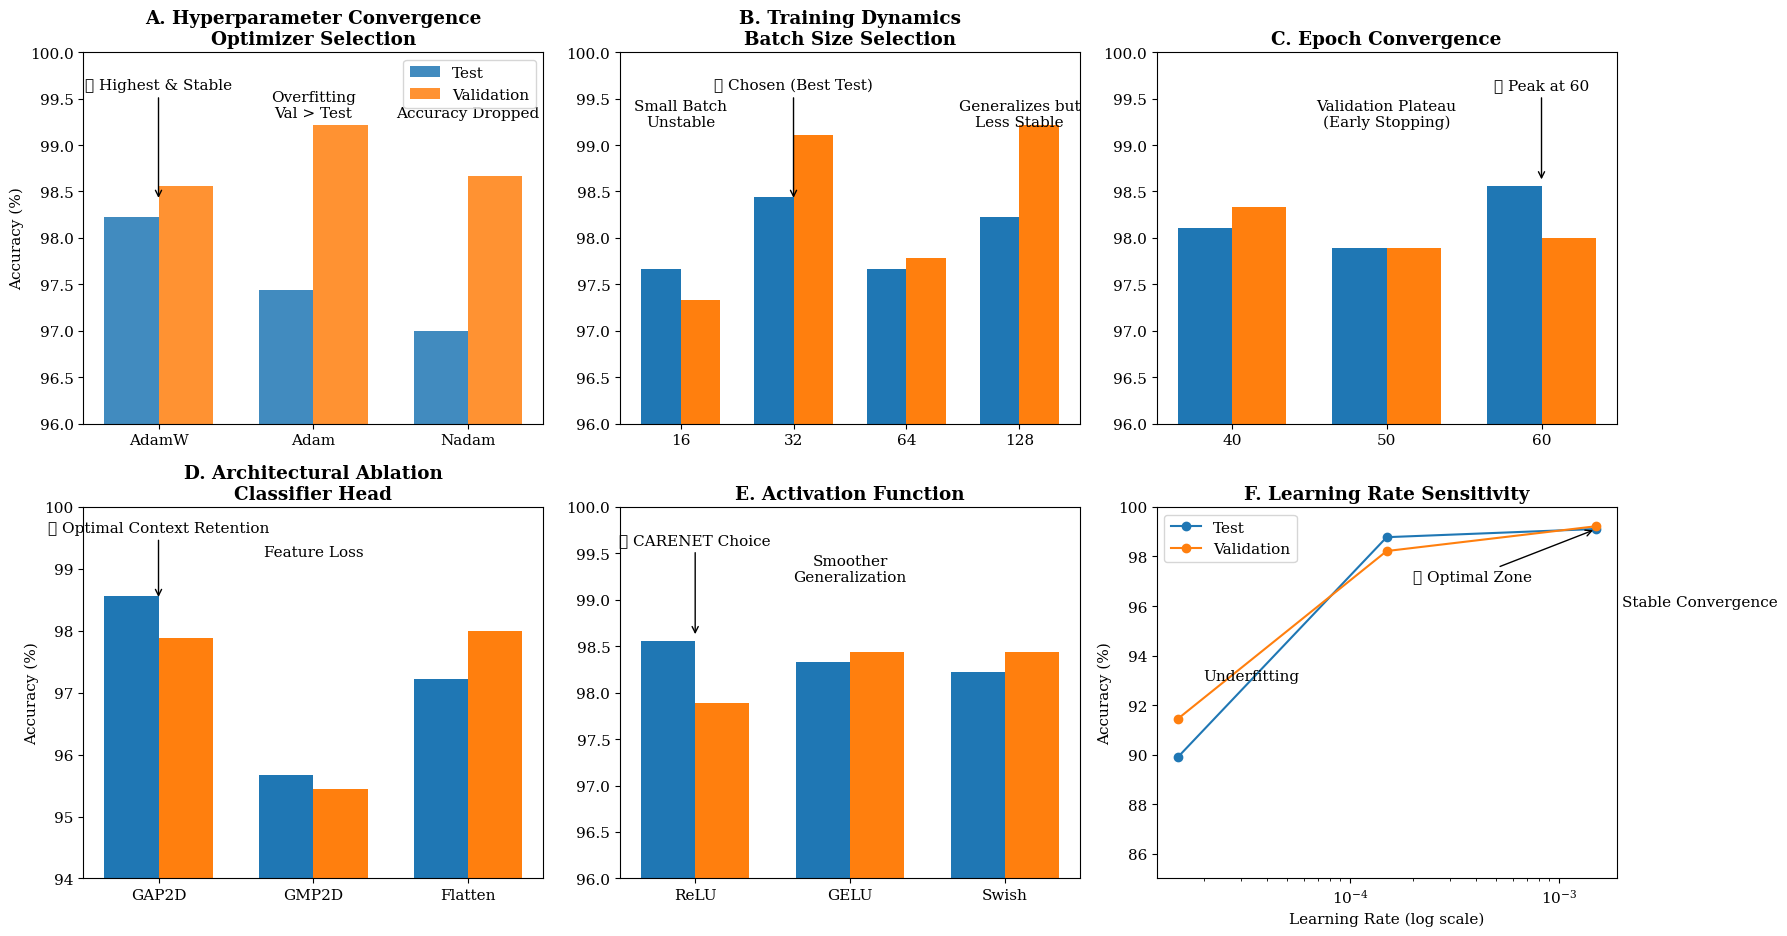

In [4]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11
})

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3)

bar_width = 0.35

# ===================== A. OPTIMIZER =====================
ax1 = fig.add_subplot(gs[0,0])
optimizers = ['AdamW', 'Adam', 'Nadam']
test_opt = [98.22, 97.44, 97.00]
val_opt = [98.56, 99.22, 98.67]

x = np.arange(len(optimizers))
ax1.bar(x-bar_width/2, test_opt, bar_width, label='Test', alpha=0.85)
ax1.bar(x+bar_width/2, val_opt, bar_width, label='Validation', alpha=0.85)

ax1.set_title("A. Hyperparameter Convergence\nOptimizer Selection",
              fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(optimizers)
ax1.set_ylim(96, 100)
ax1.set_ylabel("Accuracy (%)")

# Highlight best
ax1.annotate("⭐ Highest & Stable",
             xy=(0, 98.4), xytext=(0, 99.6),
             ha='center',
             arrowprops=dict(arrowstyle="->"))

ax1.text(1, 99.3, "Overfitting\nVal > Test", ha='center')
ax1.text(2, 99.3, "Accuracy Dropped", ha='center')

ax1.legend()


# ===================== B. BATCH SIZE =====================
ax2 = fig.add_subplot(gs[0,1])
batch = ['16', '32', '64', '128']
test_batch = [97.67, 98.44, 97.67, 98.22]
val_batch = [97.33, 99.11, 97.78, 99.22]

x = np.arange(len(batch))
ax2.bar(x-bar_width/2, test_batch, bar_width)
ax2.bar(x+bar_width/2, val_batch, bar_width)

ax2.set_title("B. Training Dynamics\nBatch Size Selection",
              fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(batch)
ax2.set_ylim(96, 100)

ax2.annotate("⭐ Chosen (Best Test)",
             xy=(1, 98.4), xytext=(1, 99.6),
             ha='center',
             arrowprops=dict(arrowstyle="->"))

ax2.text(0, 99.2, "Small Batch\nUnstable", ha='center')
ax2.text(3, 99.2, "Generalizes but\nLess Stable", ha='center')


# ===================== C. EPOCHS =====================
ax3 = fig.add_subplot(gs[0,2])
epochs = ['40', '50', '60']
test_ep = [98.11, 97.89, 98.56]
val_ep = [98.33, 97.89, 98.00]

x = np.arange(len(epochs))
ax3.bar(x-bar_width/2, test_ep, bar_width)
ax3.bar(x+bar_width/2, val_ep, bar_width)

ax3.set_title("C. Epoch Convergence",
              fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(epochs)
ax3.set_ylim(96, 100)

ax3.annotate("⭐ Peak at 60",
             xy=(2, 98.6), xytext=(2, 99.6),
             ha='center',
             arrowprops=dict(arrowstyle="->"))

ax3.text(1, 99.2, "Validation Plateau\n(Early Stopping)", ha='center')


# ===================== D. CLASSIFIER HEAD =====================
ax4 = fig.add_subplot(gs[1,0])
heads = ['GAP2D', 'GMP2D', 'Flatten']
test_head = [98.56, 95.67, 97.22]
val_head = [97.89, 95.44, 98.00]

x = np.arange(len(heads))
ax4.bar(x-bar_width/2, test_head, bar_width)
ax4.bar(x+bar_width/2, val_head, bar_width)

ax4.set_title("D. Architectural Ablation\nClassifier Head",
              fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(heads)
ax4.set_ylim(94, 100)
ax4.set_ylabel("Accuracy (%)")

ax4.annotate("⭐ Optimal Context Retention",
             xy=(0, 98.5), xytext=(0, 99.6),
             ha='center',
             arrowprops=dict(arrowstyle="->"))

ax4.text(1, 99.2, "Feature Loss", ha='center')


# ===================== E. ACTIVATION =====================
ax5 = fig.add_subplot(gs[1,1])
act = ['ReLU', 'GELU', 'Swish']
test_act = [98.56, 98.33, 98.22]
val_act = [97.89, 98.44, 98.44]

x = np.arange(len(act))
ax5.bar(x-bar_width/2, test_act, bar_width)
ax5.bar(x+bar_width/2, val_act, bar_width)

ax5.set_title("E. Activation Function",
              fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(act)
ax5.set_ylim(96, 100)

ax5.annotate("⭐ CARENET Choice",
             xy=(0, 98.6), xytext=(0, 99.6),
             ha='center',
             arrowprops=dict(arrowstyle="->"))

ax5.text(1, 99.2, "Smoother\nGeneralization", ha='center')


# ===================== F. LEARNING RATE =====================
ax6 = fig.add_subplot(gs[1,2])
lr = [0.000015, 0.00015, 0.0015]
test_lr = [89.89, 98.78, 99.11]
val_lr = [91.44, 98.22, 99.22]

ax6.plot(lr, test_lr, marker='o', label='Test')
ax6.plot(lr, val_lr, marker='o', label='Validation')

ax6.set_xscale('log')
ax6.set_title("F. Learning Rate Sensitivity",
              fontweight='bold')
ax6.set_xlabel("Learning Rate (log scale)")
ax6.set_ylabel("Accuracy (%)")
ax6.set_ylim(85, 100)

ax6.annotate("⭐ Optimal Zone",
             xy=(0.0015, 99.1),
             xytext=(0.0002, 97),
             arrowprops=dict(arrowstyle="->"))

ax6.text(0.00002, 93, "Underfitting")
ax6.text(0.002, 96, "Stable Convergence")

ax6.legend()

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("carenet_ablation_annotated.png", dpi=1200)
plt.show()

Layers used for visualization: ['reshape', 'multiply', 'concatenate', 'conv2d', 'multiply_1']
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


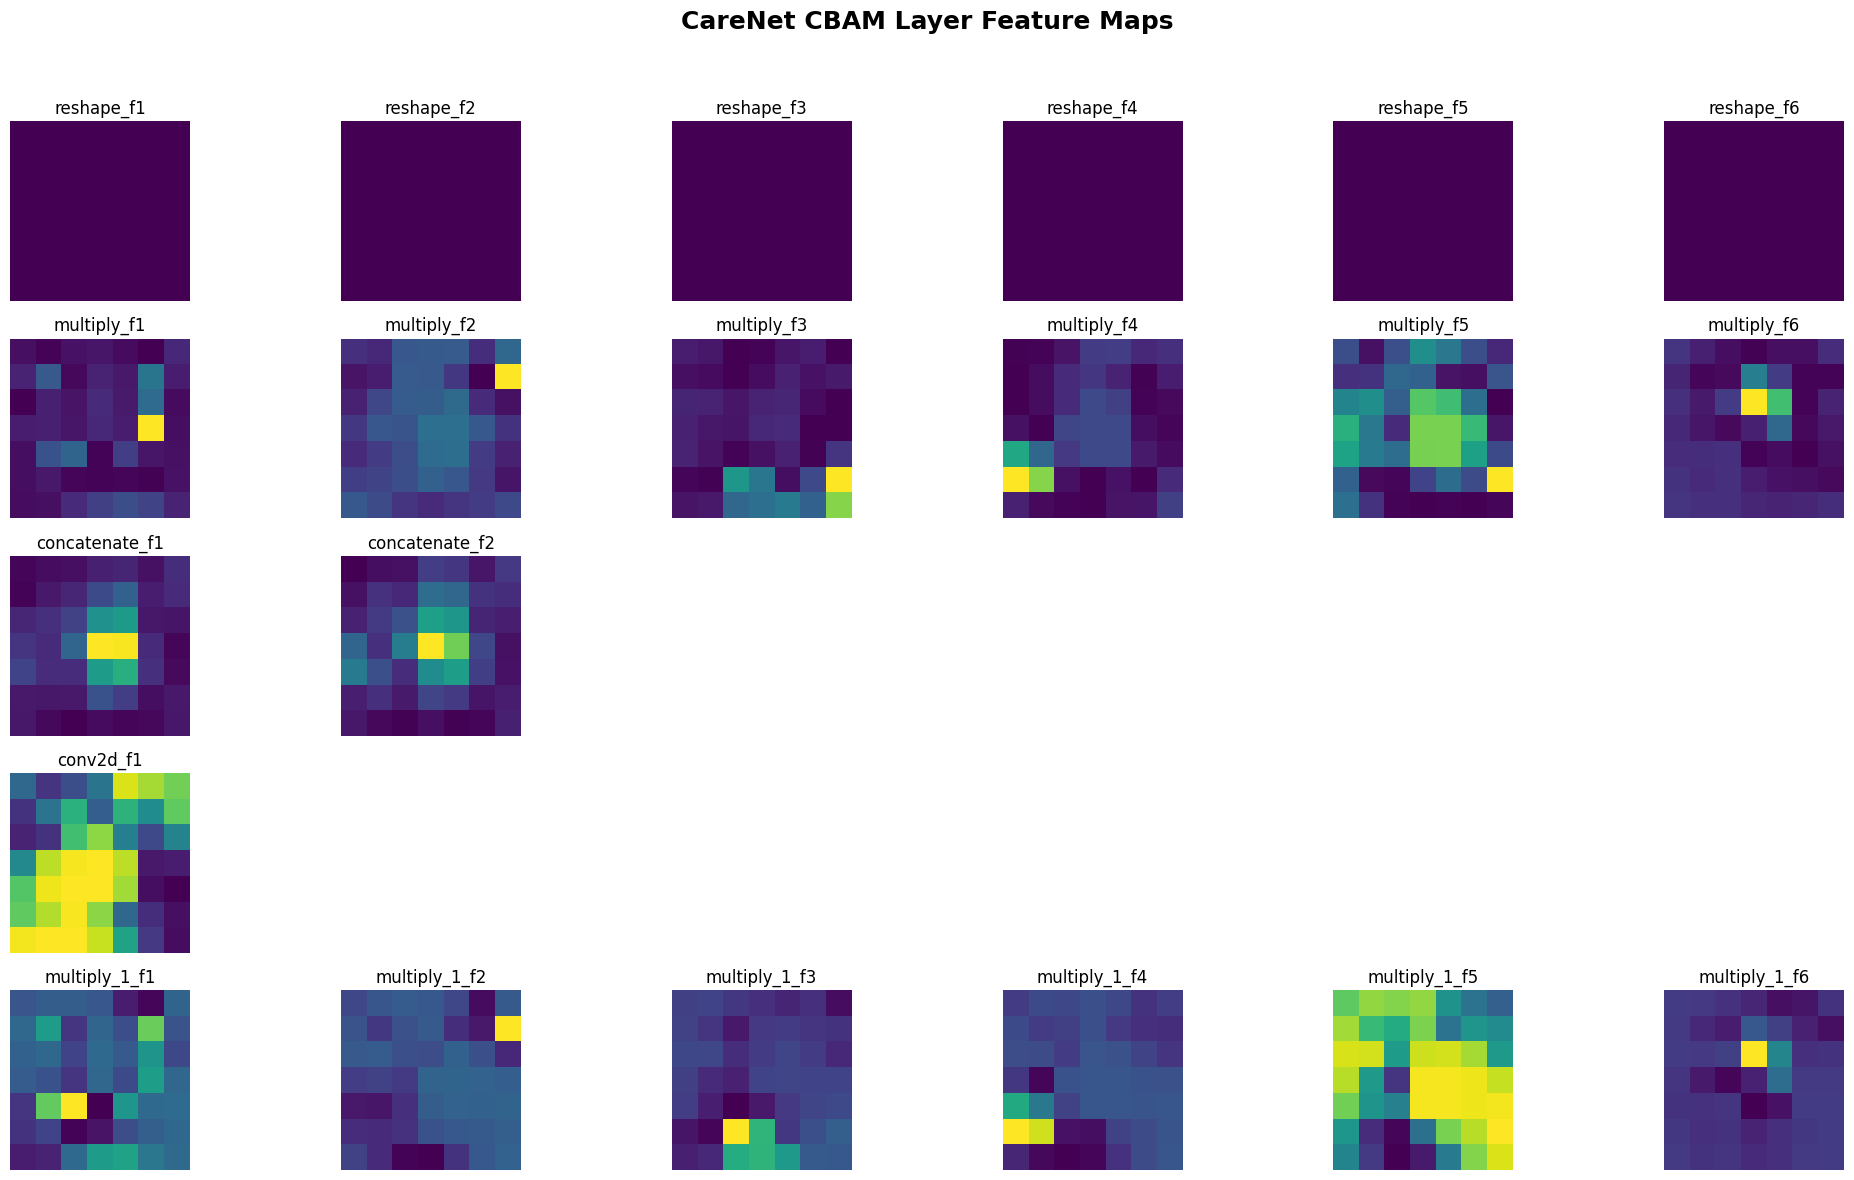

In [6]:
# ================= IMPORTS =================
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image

# ================= LOAD IMAGE =================
img_path = "/kaggle/input/datasets/mariyahossan/colon-augmented-custom/colon_augmented_png_v9/2_polyps/test_polyps_ (10)_aug.png"
img_size = (224, 224)

img = image.load_img(img_path, target_size=img_size)
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# ================= LOAD TRAINED MODEL =================
model = tf.keras.models.load_model(
    "/kaggle/working/carenet.keras",
    compile=False
)

# ================= SELECT LAYERS TO VISUALIZE =================
# Skip the full EfficientNet backbone, focus on CBAM layers
layer_names = [
    "reshape",
    "multiply",
    "concatenate",
    "conv2d",
    "multiply_1"
]

print("Layers used for visualization:", layer_names)

# ================= CREATE FEATURE EXTRACTION MODEL =================
layer_outputs = [model.get_layer(name).output for name in layer_names]

feature_model = Model(
    inputs=model.input,
    outputs=layer_outputs
)

# ================= PREDICT FEATURES =================
features = feature_model.predict(img_array)

# ================= FUNCTION TO GENERATE HEATMAP =================
def generate_heatmap(feature):
    """
    Compute mean across channels, apply ReLU, and normalize.
    """
    if len(feature.shape) == 2:  # single channel
        heatmap = feature
    else:  # H x W x C
        heatmap = np.mean(feature, axis=-1)
    
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (np.max(heatmap) + 1e-8)
    return heatmap

# ================= ORIGINAL IMAGE =================
original_img = cv2.imread(img_path)
original_img = cv2.resize(original_img, img_size)

# ================= VISUALIZE FEATURE MAPS =================
plt.figure(figsize=(20, 12))

for layer_index, feature in enumerate(features):
    feature_map = feature[0]  # remove batch dimension
    num_filters = feature_map.shape[-1] if len(feature_map.shape) == 3 else 1
    display_filters = min(num_filters, 6)  # show up to 6 feature maps per layer

    for i in range(display_filters):
        plt.subplot(len(features), 6, layer_index*6 + i + 1)
        if len(feature_map.shape) == 3:
            plt.imshow(feature_map[:, :, i], cmap='viridis')
        else:
            plt.imshow(feature_map, cmap='viridis')
        plt.axis("off")
        plt.title(f"{layer_names[layer_index]}_f{i+1}")

plt.suptitle("CareNet CBAM Layer Feature Maps", fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

In [7]:
# ================= IMPORTS =================
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image

# ================= LOAD IMAGE =================
img_path = "/kaggle/input/datasets/mariyahossan/colon-augmented-custom/colon_augmented_png_v9/2_polyps/test_polyps_ (10)_aug.png"
img_size = (224, 224)

img = image.load_img(img_path, target_size=img_size)
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# ================= LOAD TRAINED MODEL =================
model = tf.keras.models.load_model(
    "/kaggle/working/carenet.keras",
    compile=False
)

# ================= SELECT LAYERS TO VISUALIZE =================
layer_names = [
    "reshape",
    "multiply",
    "concatenate",
    "conv2d",
    "multiply_1"
]

print("Layers used for visualization:", layer_names)

# ================= CREATE FEATURE EXTRACTION MODEL =================
layer_outputs = [model.get_layer(name).output for name in layer_names]

feature_model = Model(
    inputs=model.input,
    outputs=layer_outputs
)

# ================= PREDICT FEATURES =================
features = feature_model.predict(img_array)

# ================= FUNCTION TO GENERATE HEATMAP =================
def generate_heatmap(feature):
    """
    Compute mean across channels, apply ReLU, and normalize.
    """
    if len(feature.shape) == 2:  # single channel
        heatmap = feature
    else:  # H x W x C
        heatmap = np.mean(feature, axis=-1)
    
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (np.max(heatmap) + 1e-8)
    return heatmap

# ================= ORIGINAL IMAGE =================
original_img = cv2.imread(img_path)
original_img = cv2.resize(original_img, img_size)

# ================= VISUALIZE FEATURE MAPS =================
plt.figure(figsize=(20, 12))

for layer_index, feature in enumerate(features):
    feature_map = feature[0]  # remove batch dimension
    num_filters = feature_map.shape[-1] if len(feature_map.shape) == 3 else 1
    display_filters = min(num_filters, 6)  # show up to 6 feature maps per layer

    for i in range(display_filters):
        plt.subplot(len(features), 6, layer_index*6 + i + 1)
        if len(feature_map.shape) == 3:
            plt.imshow(feature_map[:, :, i], cmap='viridis')
        else:
            plt.imshow(feature_map, cmap='viridis')
        plt.axis("off")
        plt.title(f"{layer_names[layer_index]}_f{i+1}")

plt.suptitle("CareNet CBAM Layer Feature Maps", fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.95])

# ================= SAVE FIGURE =================
plt.savefig("carenet_feature_maps.png", dpi=1200, bbox_inches='tight')
plt.close()
print("✅ Feature maps saved at 1200 dpi as 'carenet_feature_maps.png'")

Layers used for visualization: ['reshape', 'multiply', 'concatenate', 'conv2d', 'multiply_1']
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
✅ Feature maps saved at 1200 dpi as 'carenet_feature_maps.png'
